# HR Analytics – Employee Attrition & Performance

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses employee attrition (turnover) using IBM’s HR dataset. It identifies which factors (income, overtime, job satisfaction, tenure) are most strongly associated with employees leaving the company. The insights help HR teams design retention strategies.

## Dataset
- **Source:** Kaggle – IBM HR Analytics
- **Rows:** 1,470 employees
- **Columns:** Attrition, Age, MonthlyIncome, JobSatisfaction, WorkLifeBalance, YearsAtCompany, Department, OverTime, MaritalStatus, etc.

## Key Steps
1. Load and clean data
2. Explore attrition by demographic and job factors
3. Visualise relationships using various chart types
4. Build a simple logistic regression model to rank feature importance
5. Provide actionable recommendations

## Requirements
- pandas, matplotlib, seaborn, scikit-learn

---

**© 2026 Ibrahim – HR analytics for attrition prediction.**

### Install & Imports

In [ ]:
!pip install -q pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [18]:
# Download from public URL (or upload manually)
data = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7


### Data Cleaning & Preparation

In [19]:
# Rename target column for convenience
if 'Attrition' in df.columns:
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Drop EmployeeNumber and StandardHours (constant) if present
df = df.drop(columns=['EmployeeNumber', 'StandardHours'], errors='ignore')

# Check missing values
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

print(f"Attrition rate: {df['Attrition'].mean()*100:.2f}%")

Missing values:
 Series([], dtype: int64)
Attrition rate: 16.12%


### Attrition Rate Overall and by Department

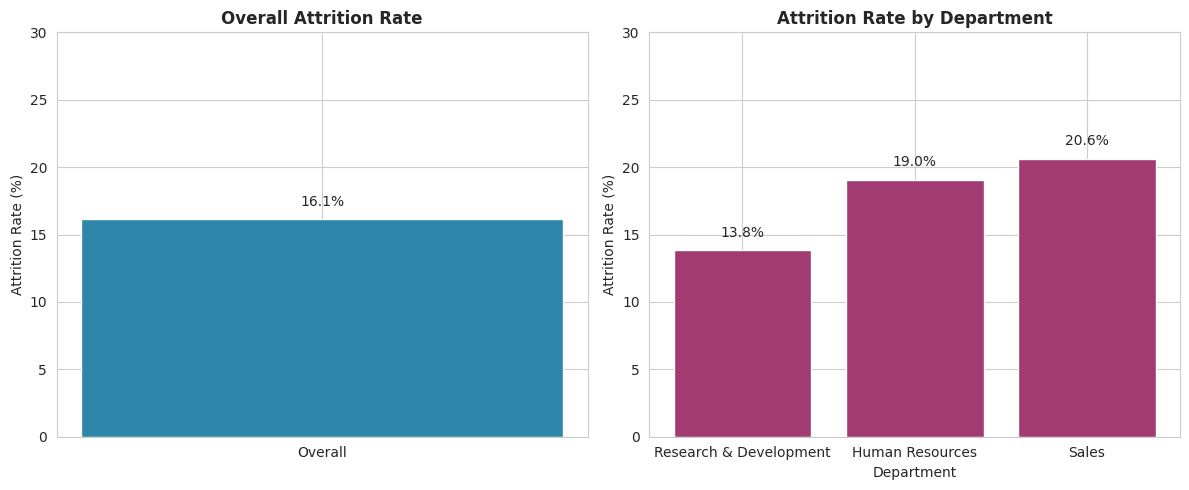

In [20]:
dept_attrition = df.groupby('Department')['Attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values()

plt.figure(figsize=(12, 5))

# Overall attrition rate
plt.subplot(1, 2, 1)
overall = df['Attrition'].mean() * 100
plt.bar(['Overall'], [overall], color='#2E86AB')
plt.ylim(0, 30)
plt.ylabel('Attrition Rate (%)')
plt.title('Overall Attrition Rate', fontweight='bold')
for i, v in enumerate([overall]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

# By department
plt.subplot(1, 2, 2)
bars = plt.bar(dept_attrition.index, dept_attrition.values, color='#A23B72')
plt.ylim(0, 30)
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### Monthly Income Distribution by Attrition

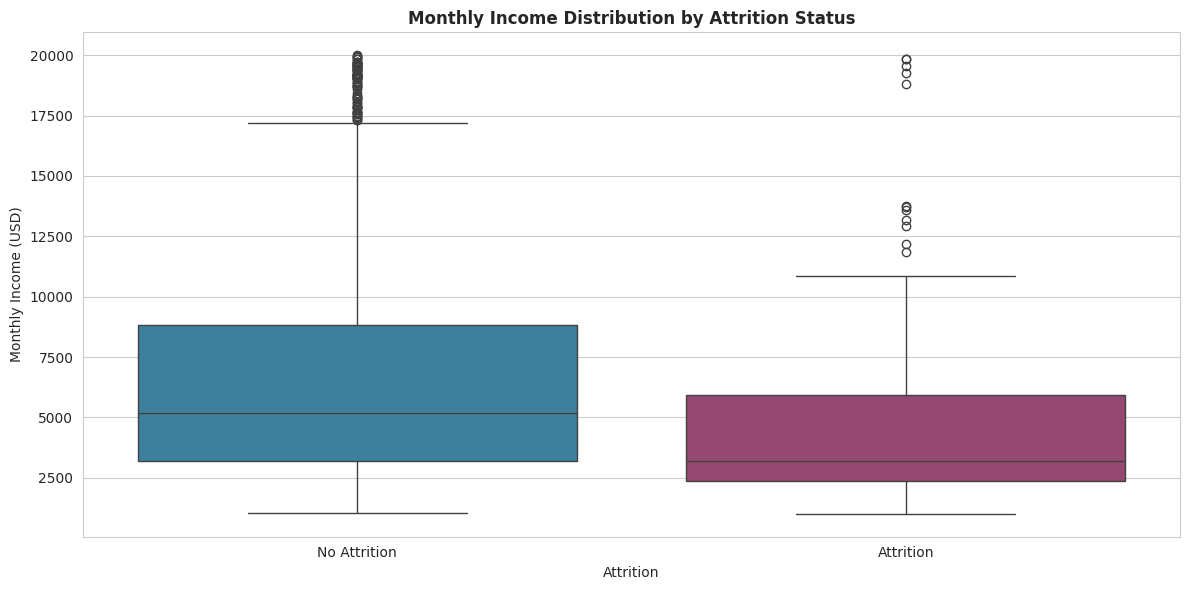

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['No Attrition', 'Attrition'])
plt.ylabel('Monthly Income (USD)')
plt.title('Monthly Income Distribution by Attrition Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Age Distribution by Attrition

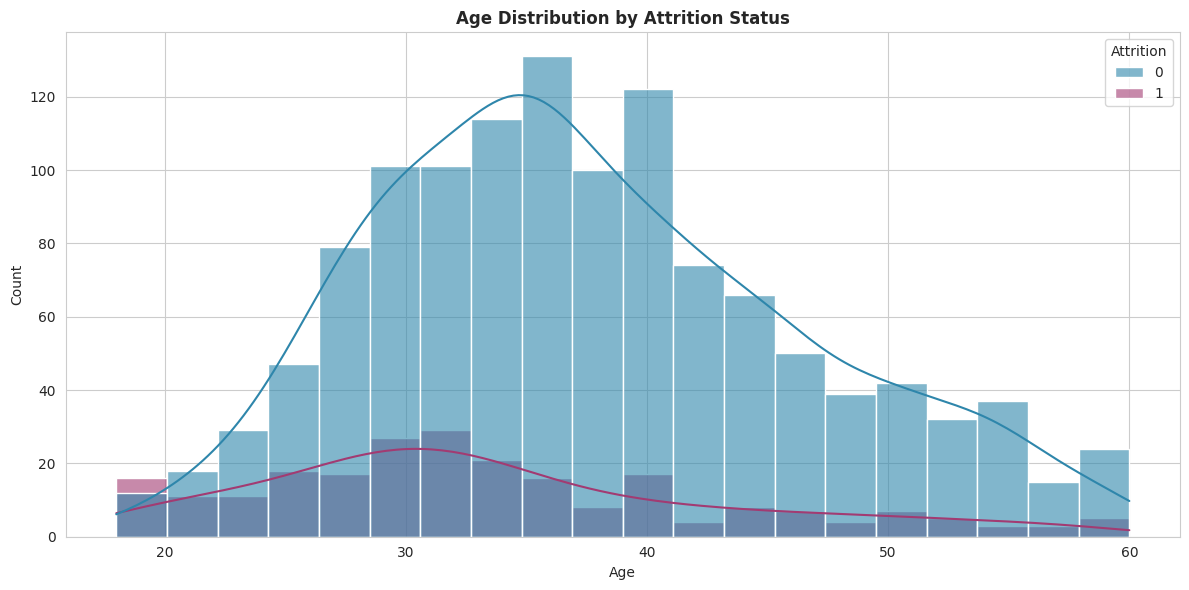

In [22]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.title('Age Distribution by Attrition Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Job Satisfaction vs Attrition

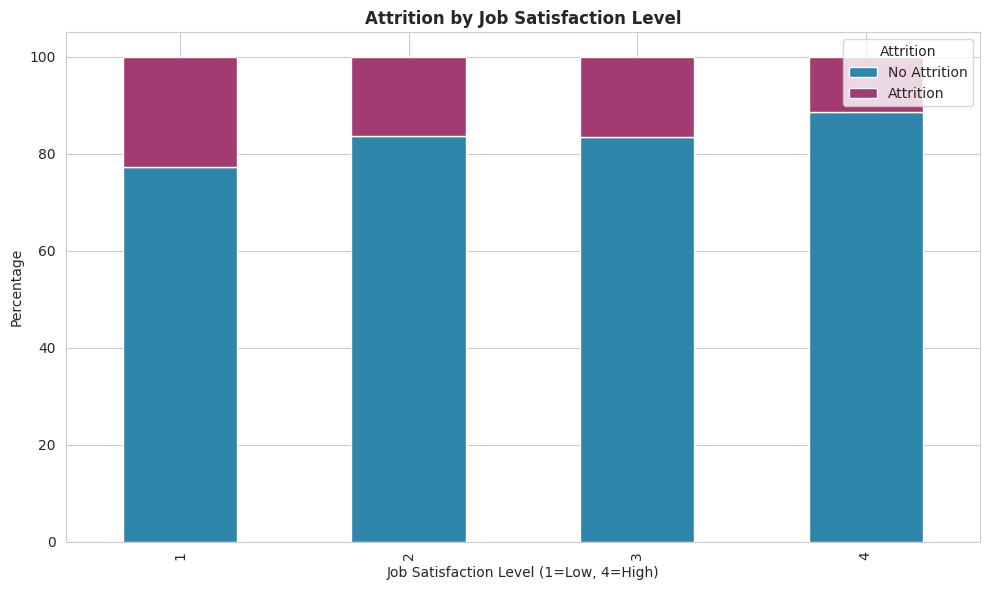

In [23]:
sat_attrition = pd.crosstab(df['JobSatisfaction'], df['Attrition'], normalize='index') * 100
sat_attrition.columns = ['No Attrition', 'Attrition']

sat_attrition.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2E86AB', '#A23B72'])
plt.xlabel('Job Satisfaction Level (1=Low, 4=High)')
plt.ylabel('Percentage')
plt.title('Attrition by Job Satisfaction Level', fontweight='bold')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### Years at Company vs Attrition (Box Plot)

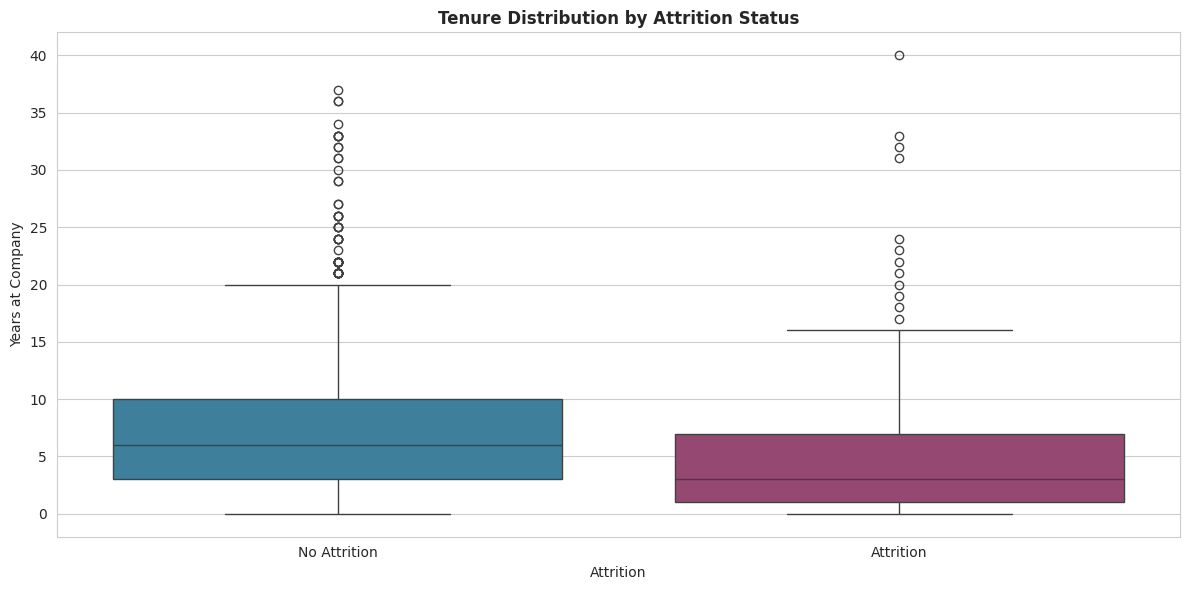

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['No Attrition', 'Attrition'])
plt.ylabel('Years at Company')
plt.title('Tenure Distribution by Attrition Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Overtime Impact on Attrition

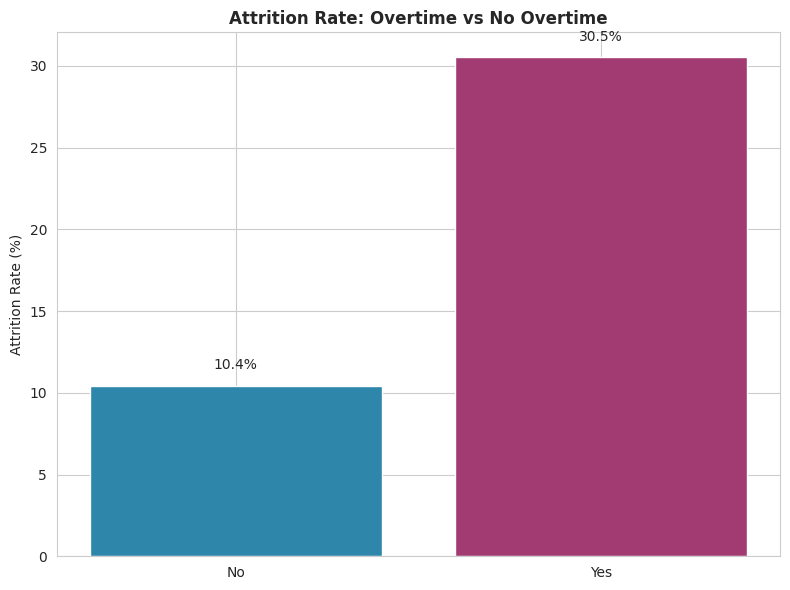

In [25]:
overtime_attrition = df.groupby('OverTime')['Attrition'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(overtime_attrition.index, overtime_attrition.values, color=['#2E86AB', '#A23B72'])
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate: Overtime vs No Overtime', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### Marital Status vs Attrition

<Figure size 800x600 with 0 Axes>

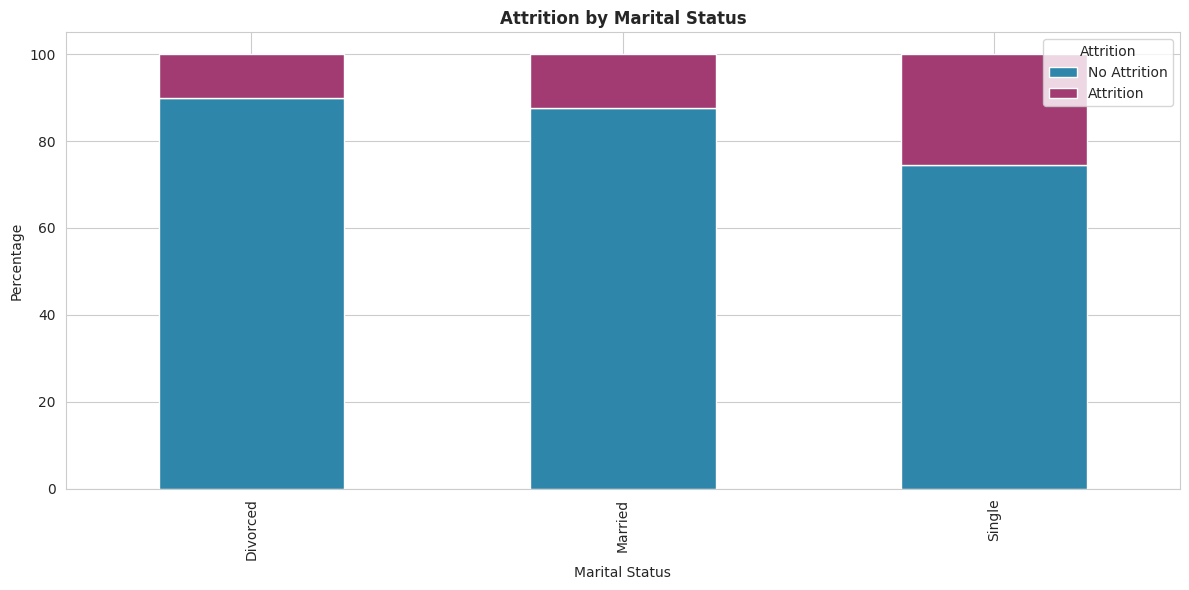

In [26]:
marital_attrition = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index') * 100
marital_attrition.columns = ['No Attrition', 'Attrition']

plt.figure(figsize=(8, 6))
marital_attrition.plot(kind='bar', stacked=True, color=['#2E86AB', '#A23B72'])
plt.xlabel('Marital Status')
plt.ylabel('Percentage')
plt.title('Attrition by Marital Status', fontweight='bold')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

### Correlation Heatmap

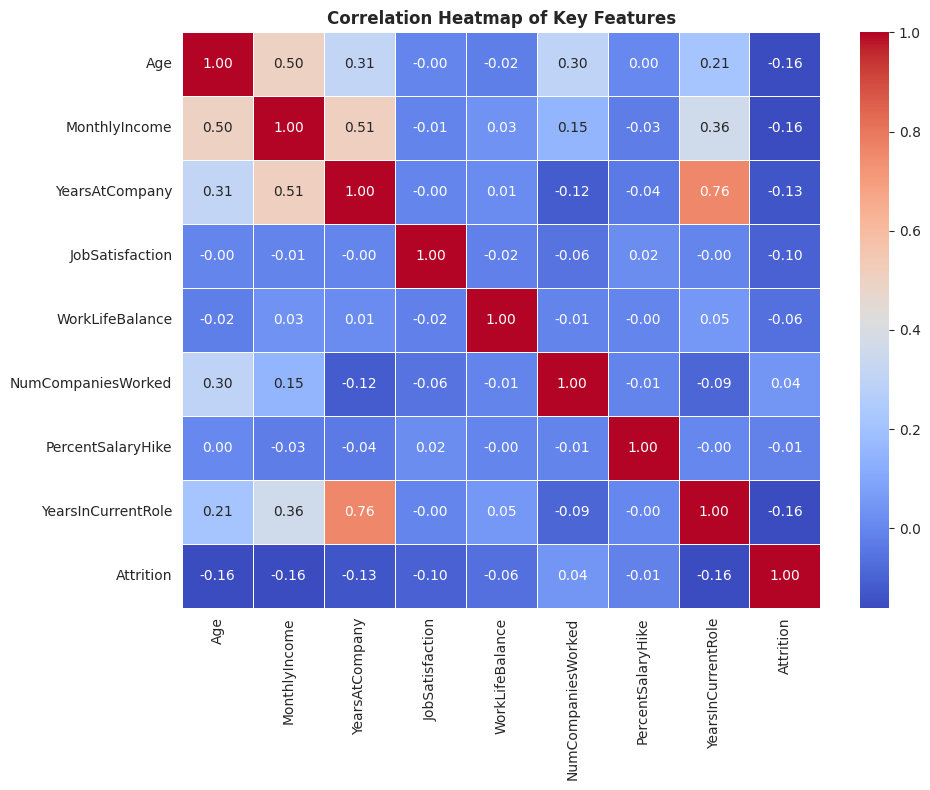

In [27]:
numeric_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance',
                'NumCompaniesWorked', 'PercentSalaryHike', 'YearsInCurrentRole', 'Attrition']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance from Logistic Regression

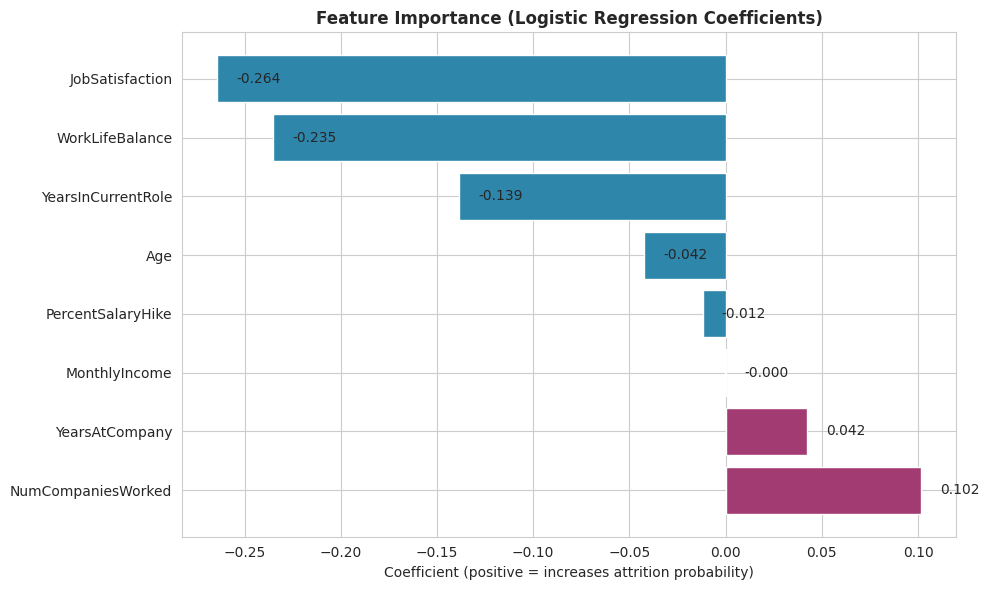

In [29]:
from sklearn.linear_model import LogisticRegression

# Prepare data for logistic regression
features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance',
            'NumCompaniesWorked', 'PercentSalaryHike', 'YearsInCurrentRole']
X = df[features]
y = df['Attrition']

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Feature importance (coefficients)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=['#A23B72' if c>0 else '#2E86AB' for c in coef_df['Coefficient']])
plt.xlabel('Coefficient (positive = increases attrition probability)')
plt.title('Feature Importance (Logistic Regression Coefficients)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')
plt.tight_layout()
plt.show()

### Department-wise Attrition Percentage (Horizontal Bar)

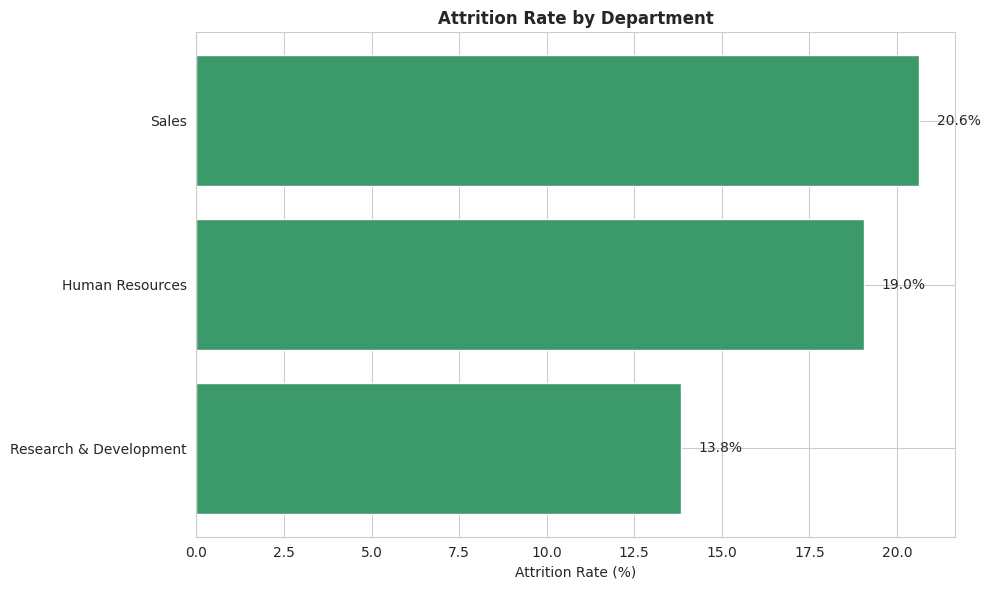

In [30]:
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values() * 100

plt.figure(figsize=(10, 6))
bars = plt.barh(dept_attrition.index, dept_attrition.values, color='#3C9A6A')
plt.xlabel('Attrition Rate (%)')
plt.title('Attrition Rate by Department', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [32]:
print(" Key Insights from HR Attrition Analysis")
print(f" Overall attrition rate: {df['Attrition'].mean()*100:.2f}%")
print(f" Average monthly income (leavers vs stayers): ${df[df['Attrition']==0]['MonthlyIncome'].mean():.0f} vs ${df[df['Attrition']==1]['MonthlyIncome'].mean():.0f}")
print(f" Employees who work overtime are {overtime_attrition['Yes']:.1f}% more likely to leave")
print(f" Most influential factor for attrition: {coef_df.iloc[0]['Feature']} (coefficient {coef_df.iloc[0]['Coefficient']:.3f})")
print(f" Average tenure for leavers: {df[df['Attrition']==1]['YearsAtCompany'].mean():.1f} years")
print(" Recommendations: Focus retention on junior employees, those with overtime, and low job satisfaction.")

 Key Insights from HR Attrition Analysis
 Overall attrition rate: 16.12%
 Average monthly income (leavers vs stayers): $6833 vs $4787
 Employees who work overtime are 30.5% more likely to leave
 Most influential factor for attrition: NumCompaniesWorked (coefficient 0.102)
 Average tenure for leavers: 5.1 years
 Recommendations: Focus retention on junior employees, those with overtime, and low job satisfaction.


### Final Summary

In [33]:
print("HR Analytics – Employee Attrition Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Key attrition drivers identified.")
print("Visualisations ready for HR presentation.")

HR Analytics – Employee Attrition Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Key attrition drivers identified.
Visualisations ready for HR presentation.
